## Import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneGroupOut,
    cross_validate, cross_val_predict, cross_val_score,
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.metrics import f1_score, roc_auc_score
import shap
shap.initjs()

## Load data

In [17]:
# Load gex_mat_corrected
gex_mat = pd.read_csv(f"../dataset/created/gex_mat_corrected.csv").set_index('sample_id').T
gex_mat['sample_id'] = gex_mat.index

print(gex_mat.shape)
gex_mat.head()

(78, 23387)


sample_id,A1BG-AS1,A1CF,A2M-AS1,A2ML1,A3GALT2,A4GALT,A4GNT,AA06,AAAS,AACS,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample_id
03660555B,0.892848,-0.014449,2.669098,0.016093,-0.250163,2.143437,-0.206612,0.0,5.553840,3.031676,...,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248,03660555B
03660598B,1.250526,-0.021733,3.973917,0.282158,-0.119886,1.474063,-0.020543,0.0,5.496134,3.183949,...,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618,03660598B
03660602B,1.337167,-0.014759,2.973871,0.194465,-0.122425,1.704613,0.318386,0.0,4.832991,2.218299,...,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558,03660602B
04240076F,0.696176,-0.019675,2.393908,0.602224,-0.202191,2.990010,0.042588,0.0,4.535571,2.436898,...,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254,04240076F
04240106F,1.178242,-0.030725,2.639825,0.045172,0.665199,1.758596,-0.171676,0.0,5.661363,2.146097,...,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455,04240106F


In [18]:
# Load clinical_gex
clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex.csv", low_memory=False)

print(clinical_gex.shape)
clinical_gex.head()

(78, 51483)


,patientID,sex,age,AJCC_stage,M_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,source,pfs_label,...,sept-05,sept-06,sept-07,sept-08,sept-09,sept-10,sept-11,sept-12,sept-14,sept-15
0,YR_3053,male,26,IV,M1B,elevated,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,YR_3708,female,58,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,YR_3705,male,45,IV,M1A,normal,no,no,Yan et al.,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,YR_1106,male,48,IIIC,NaN,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,YR_1110,male,33,IV,M1C,normal,no,no,Yan et al.,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Clinical feature groups
clinical_ordinal_col    = ['M_stage']
clinical_categorical_cols = ['sex', 'AJCC_stage', 'LDH', 'immunotherapy_treatment', 'pre_MAPKi_treatment']
clinical_numeric_col    = ['age']
clinical_drug_braf_cols = ['cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
                           'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'] 
clinical_remaining_cols = ['patientID', 'sample_id', 'pfs_label', 'source']

In [20]:
# sometime certain drugs or gene are missing in the dataset
clinical_drug_braf_cols = [c for c in clinical_drug_braf_cols if c in clinical_gex.columns]

CLINICAL_COLS = (clinical_ordinal_col + clinical_categorical_cols + clinical_numeric_col
                + clinical_drug_braf_cols + clinical_remaining_cols)

GEX_COLS_ORI = [c for c in clinical_gex.columns if c not in CLINICAL_COLS]

print('Original clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_ORI)} = {len(CLINICAL_COLS)+len(GEX_COLS_ORI)}')

Original clinical_gex features:
clinical + gex = 18 + 51465 = 51483


In [21]:
# Merge into clinical_gex_corrected
clinical_gex_filtered = clinical_gex[CLINICAL_COLS]
clinical_gex_filtered

clinical_gex_filtered = clinical_gex_filtered.merge(gex_mat, on='sample_id', how='inner')
print(clinical_gex_filtered.shape)
clinical_gex_filtered.head()

(78, 23404)


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.671622,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.973160,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.652098,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.360416,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.004662,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455


In [22]:
GEX_COLS_FILTERED = [c for c in clinical_gex_filtered.columns if c not in CLINICAL_COLS]

print('Filtered clinical_gex features:')
print(f'clinical + gex = {len(CLINICAL_COLS)} + {len(GEX_COLS_FILTERED)} = {len(CLINICAL_COLS)+len(GEX_COLS_FILTERED)}')

Filtered clinical_gex features:
clinical + gex = 18 + 23386 = 23404


In [23]:
from sklearn.model_selection import train_test_split

# Split x, y
clinical_gex_filtered.columns = clinical_gex_filtered.columns.str.strip()

y = clinical_gex_filtered['pfs_label']
x = clinical_gex_filtered.drop(clinical_remaining_cols, axis=1)

print(f'Dropped {len(clinical_remaining_cols)} clinical cols, {x.shape} remaining')
x.head()

Dropped 4 clinical cols, (78, 23400) remaining


,M_stage,sex,AJCC_stage,LDH,immunotherapy_treatment,pre_MAPKi_treatment,age,cobimetinib,trametinib,dabrafenib,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,M1B,male,IV,elevated,no,no,26,0,0,0,...,2.671622,3.097789,0.556946,1.192834,2.773766,0.052665,2.079754,6.546661,2.954971,2.939248
1,M1A,female,IV,normal,no,no,58,0,0,0,...,2.973160,3.505208,0.697100,1.042928,2.612191,-0.003464,2.432721,5.618133,2.969150,2.586618
2,M1A,male,IV,normal,no,no,45,0,0,0,...,3.652098,2.859687,0.707183,1.066919,2.500457,0.260227,2.217228,6.528220,3.161277,3.463558
3,NaN,male,IIIC,normal,no,no,48,1,0,0,...,2.360416,2.718169,0.797301,1.066046,2.408641,-0.027371,2.047882,6.690812,3.135011,2.232254
4,M1C,male,IV,normal,no,no,33,1,0,0,...,3.004662,1.821515,0.810193,1.336957,2.891467,-0.052370,2.847988,5.547082,3.319700,3.505455


In [24]:
if y.nunique() == 2:
    BINARY_PFS = True
elif y.nunique() == 3:
    BINARY_PFS = False
else:
    raise ValueError('NOT BINARY NOR 3 CLASSES!!')

In [25]:
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")


Target distribution:
pfs_label
0    47
1    31
Name: count, dtype: int64


## Count overlap with KEGG-VECLLS

In [26]:
with open("../dataset/additional/combine-kegg-vcells.txt") as f:
    kegg_vcells = {g.strip() for g in f.read().split(",")}

GEX_COLS_KEGG = [g for g in GEX_COLS_FILTERED if g in kegg_vcells]

print(f"combine-kegg-vcells genes : {len(kegg_vcells)}")
print(f"GEX_COLS_FILTERED genes   : {len(GEX_COLS_FILTERED)}")
print(f"Overlap (GEX_COLS_KEGG)   : {len(GEX_COLS_KEGG)}")


combine-kegg-vcells genes : 174
GEX_COLS_FILTERED genes   : 23386
Overlap (GEX_COLS_KEGG)   : 173


In [27]:
k = 10
x_kegg = x[GEX_COLS_KEGG].fillna(0)
x_full = x[GEX_COLS_FILTERED].fillna(0)

kb_kegg = SelectKBest(f_classif, k=min(k, len(GEX_COLS_KEGG))).fit(x_kegg, y)
kb_full = SelectKBest(f_classif, k=k).fit(x_full, y)

kegg_scores = pd.Series(kb_kegg.scores_, index=GEX_COLS_KEGG).nlargest(k)
full_scores  = pd.Series(kb_full.scores_,  index=GEX_COLS_FILTERED).nlargest(k)

print(f"Top {k} from GEX_COLS_KEGG ({len(GEX_COLS_KEGG)} genes):")
print(kegg_scores.round(3).to_string())

print(f"\nTop {k} from GEX_COLS_FILTERED ({len(GEX_COLS_FILTERED)} genes):")
print(full_scores.round(3).to_string())

in_kegg = [g for g in full_scores.index if g in kegg_vcells]
print(f"\nOf the top {k} from all genes, {len(in_kegg)} are in kegg-vcells: {in_kegg}")

Top 10 from GEX_COLS_KEGG (173 genes):
FOXO3       7.703
GNA12       6.539
SKI         6.468
MMP14       6.377
MAPKAPK2    6.021
PDPK1       5.795
MAPK1       5.343
PLCG1       5.318
PRKAA1      5.163
PDGFRB      5.032

Top 10 from GEX_COLS_FILTERED (23386 genes):
ALDH5A1     18.954
CXCR5       16.364
SLC25A26    15.407
STX2        15.220
DOCK1       15.109
NME7        14.926
MIR23B      14.909
TTYH3       14.045
FANCC       13.447
NOTCH1      13.318

Of the top 10 from all genes, 0 are in kegg-vcells: []


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [    7  1030  1299  1580  1678  1790  2099  2244  2245  2524  2790  2791
  2793  3720  3885  3914  4190  4191  4197  4198  4201  4202  4203  4205
  4206  4217  4226  4232  4592  4725  4727  4971  5424  5451  5483  5484
  5512  5539  5582  5583  5787  5804  6515  7491  7539  8125  8192  9023
  9024  9036  9045  9050  9074  9084  9086

## Preprocessing Pipeline

In [28]:
preprocess_features = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan,
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age',      SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough',                   clinical_drug_braf_cols),

        ('gex', Pipeline([
            ('variance', VarianceThreshold(threshold=0.1)),
            ('kbest',    SelectKBest(f_classif, k=10)),
        ]), GEX_COLS_FILTERED),
    ],
    remainder='drop',
)

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf = LogisticRegression(
    solver='saga',
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    # C=1.0,
    # l1_ratio=0
)

full_pipe = Pipeline([
    ('preprocess', preprocess_features),
    ('scaler', StandardScaler()),
    ('clf', lr_clf)
])

full_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('m_stage', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [30]:
def objective(trial):
    params = {
            'clf__C':        trial.suggest_float('clf__C', 1e-3, 1.0, log=True),
            'clf__l1_ratio': trial.suggest_categorical('clf__l1_ratio', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.0, 1.0]),
            'preprocess__gex__kbest__k': trial.suggest_int('preprocess__gex__kbest__k', 5, 20)
        }
    
    full_pipe.set_params(**params)
    
    if BINARY_PFS == True:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(full_pipe, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)
        
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(study.best_params)
print(f"Best CV F1 (or macro F1 if 3 classes): {study.best_value:.3f}")
full_pipe.set_params(**study.best_params)

[I 2026-05-25 14:39:50,565] A new study created in memory with name: no-name-e5194a00-73e7-46e5-8b2c-bea42cb8c675
Best trial: 0. Best value: 0:   1%|          | 1/100 [00:02<04:19,  2.62s/it]

[I 2026-05-25 14:39:53,199] Trial 0 finished with value: 0.0 and parameters: {'clf__C': 0.013292918943162165, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 18}. Best is trial 0 with value: 0.0.


Best trial: 1. Best value: 0.109091:   2%|▏         | 2/100 [00:04<03:38,  2.23s/it]

[I 2026-05-25 14:39:55,148] Trial 1 finished with value: 0.10909090909090909 and parameters: {'clf__C': 0.004335281794951566, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.10909090909090909.


Best trial: 1. Best value: 0.109091:   3%|▎         | 3/100 [00:05<02:19,  1.43s/it]

[I 2026-05-25 14:39:55,639] Trial 2 finished with value: 0.10909090909090909 and parameters: {'clf__C': 0.003972110727381913, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 15}. Best is trial 1 with value: 0.10909090909090909.


Best trial: 1. Best value: 0.109091:   4%|▍         | 4/100 [00:05<01:42,  1.06s/it]

[I 2026-05-25 14:39:56,136] Trial 3 finished with value: 0.0 and parameters: {'clf__C': 0.020914981329035603, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 17}. Best is trial 1 with value: 0.10909090909090909.


Best trial: 4. Best value: 0.664103:   5%|▌         | 5/100 [00:06<01:21,  1.17it/s]

[I 2026-05-25 14:39:56,614] Trial 4 finished with value: 0.6641025641025641 and parameters: {'clf__C': 0.6584106160121611, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:   6%|▌         | 6/100 [00:06<01:09,  1.35it/s]

[I 2026-05-25 14:39:57,131] Trial 5 finished with value: 0.6028638028638029 and parameters: {'clf__C': 0.042470585622618684, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:   7%|▋         | 7/100 [00:07<01:01,  1.51it/s]

[I 2026-05-25 14:39:57,635] Trial 6 finished with value: 0.5377622377622377 and parameters: {'clf__C': 0.011895896737553546, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:   8%|▊         | 8/100 [00:07<00:57,  1.60it/s]

[I 2026-05-25 14:39:58,184] Trial 7 finished with value: 0.5034188034188034 and parameters: {'clf__C': 0.13795402040204174, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 13}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:   9%|▉         | 9/100 [00:08<00:52,  1.72it/s]

[I 2026-05-25 14:39:58,666] Trial 8 finished with value: 0.4887612387612387 and parameters: {'clf__C': 0.5280796376895364, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 17}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  10%|█         | 10/100 [00:08<00:49,  1.81it/s]

[I 2026-05-25 14:39:59,158] Trial 9 finished with value: 0.0 and parameters: {'clf__C': 0.003628358380354917, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 13}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  11%|█         | 11/100 [00:09<00:48,  1.85it/s]

[I 2026-05-25 14:39:59,672] Trial 10 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.867822400610596, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  12%|█▏        | 12/100 [00:09<00:47,  1.87it/s]

[I 2026-05-25 14:40:00,192] Trial 11 finished with value: 0.6641025641025641 and parameters: {'clf__C': 0.7335332607487682, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  13%|█▎        | 13/100 [00:10<00:46,  1.88it/s]

[I 2026-05-25 14:40:00,714] Trial 12 finished with value: 0.5578088578088578 and parameters: {'clf__C': 0.17506620109451515, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  14%|█▍        | 14/100 [00:10<00:44,  1.95it/s]

[I 2026-05-25 14:40:01,189] Trial 13 finished with value: 0.623076923076923 and parameters: {'clf__C': 0.29484083140472916, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  15%|█▌        | 15/100 [00:11<00:45,  1.88it/s]

[I 2026-05-25 14:40:01,763] Trial 14 finished with value: 0.562857142857143 and parameters: {'clf__C': 0.0811351544054357, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  16%|█▌        | 16/100 [00:11<00:45,  1.87it/s]

[I 2026-05-25 14:40:02,308] Trial 15 finished with value: 0.5726190476190476 and parameters: {'clf__C': 0.7922630451693616, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  17%|█▋        | 17/100 [00:12<00:45,  1.83it/s]

[I 2026-05-25 14:40:02,882] Trial 16 finished with value: 0.5745920745920745 and parameters: {'clf__C': 0.3177998347297765, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  18%|█▊        | 18/100 [00:12<00:43,  1.89it/s]

[I 2026-05-25 14:40:03,372] Trial 17 finished with value: 0.5473193473193473 and parameters: {'clf__C': 0.0011997872798046381, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  19%|█▉        | 19/100 [00:13<00:41,  1.94it/s]

[I 2026-05-25 14:40:03,857] Trial 18 finished with value: 0.5941724941724942 and parameters: {'clf__C': 0.060588319935713314, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  20%|██        | 20/100 [00:13<00:41,  1.94it/s]

[I 2026-05-25 14:40:04,368] Trial 19 finished with value: 0.525024975024975 and parameters: {'clf__C': 0.3244331422710274, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 20}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  21%|██        | 21/100 [00:14<00:40,  1.95it/s]

[I 2026-05-25 14:40:04,874] Trial 20 finished with value: 0.6135864135864135 and parameters: {'clf__C': 0.14545172212580385, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  22%|██▏       | 22/100 [00:14<00:39,  1.98it/s]

[I 2026-05-25 14:40:05,363] Trial 21 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.9760600431324636, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  23%|██▎       | 23/100 [00:15<00:38,  1.99it/s]

[I 2026-05-25 14:40:05,859] Trial 22 finished with value: 0.6013986013986015 and parameters: {'clf__C': 0.5276603123345243, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  24%|██▍       | 24/100 [00:15<00:35,  2.13it/s]

[I 2026-05-25 14:40:06,249] Trial 23 finished with value: 0.6402597402597403 and parameters: {'clf__C': 0.9923699789609592, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  25%|██▌       | 25/100 [00:16<00:35,  2.13it/s]

[I 2026-05-25 14:40:06,724] Trial 24 finished with value: 0.5701298701298702 and parameters: {'clf__C': 0.5056923727499805, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 12}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  26%|██▌       | 26/100 [00:16<00:35,  2.07it/s]

[I 2026-05-25 14:40:07,236] Trial 25 finished with value: 0.6186147186147186 and parameters: {'clf__C': 0.18822220249563276, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  27%|██▋       | 27/100 [00:17<00:35,  2.04it/s]

[I 2026-05-25 14:40:07,742] Trial 26 finished with value: 0.6314352314352314 and parameters: {'clf__C': 0.5514014714863984, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  28%|██▊       | 28/100 [00:17<00:36,  1.98it/s]

[I 2026-05-25 14:40:08,286] Trial 27 finished with value: 0.45103785103785105 and parameters: {'clf__C': 0.09891003206901376, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 14}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  29%|██▉       | 29/100 [00:18<00:37,  1.88it/s]

[I 2026-05-25 14:40:08,878] Trial 28 finished with value: 0.6135531135531136 and parameters: {'clf__C': 0.2621773397495655, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  30%|███       | 30/100 [00:18<00:36,  1.90it/s]

[I 2026-05-25 14:40:09,393] Trial 29 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.4272313761287089, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  31%|███       | 31/100 [00:19<00:36,  1.90it/s]

[I 2026-05-25 14:40:09,919] Trial 30 finished with value: 0.6314352314352314 and parameters: {'clf__C': 0.7088236865395606, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  32%|███▏      | 32/100 [00:19<00:36,  1.89it/s]

[I 2026-05-25 14:40:10,457] Trial 31 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.9448705792297056, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  33%|███▎      | 33/100 [00:20<00:35,  1.90it/s]

[I 2026-05-25 14:40:10,971] Trial 32 finished with value: 0.6402597402597403 and parameters: {'clf__C': 0.9331015885007554, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  34%|███▍      | 34/100 [00:20<00:34,  1.94it/s]

[I 2026-05-25 14:40:11,464] Trial 33 finished with value: 0.5701298701298702 and parameters: {'clf__C': 0.38431741508969725, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 12}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  35%|███▌      | 35/100 [00:21<00:33,  1.94it/s]

[I 2026-05-25 14:40:11,981] Trial 34 finished with value: 0.6128205128205128 and parameters: {'clf__C': 0.2339972094281719, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  36%|███▌      | 36/100 [00:21<00:32,  1.96it/s]

[I 2026-05-25 14:40:12,474] Trial 35 finished with value: 0.6314352314352314 and parameters: {'clf__C': 0.7006106687514151, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  37%|███▋      | 37/100 [00:22<00:33,  1.90it/s]

[I 2026-05-25 14:40:13,039] Trial 36 finished with value: 0.5597402597402598 and parameters: {'clf__C': 0.01459568580064972, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  38%|███▊      | 38/100 [00:22<00:31,  1.95it/s]

[I 2026-05-25 14:40:13,523] Trial 37 finished with value: 0.5535531135531135 and parameters: {'clf__C': 0.0066100686706420005, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 15}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  39%|███▉      | 39/100 [00:23<00:30,  1.98it/s]

[I 2026-05-25 14:40:14,005] Trial 38 finished with value: 0.6193473193473193 and parameters: {'clf__C': 0.024147603388132596, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  40%|████      | 40/100 [00:23<00:29,  2.02it/s]

[I 2026-05-25 14:40:14,483] Trial 39 finished with value: 0.5552447552447553 and parameters: {'clf__C': 0.04184061796341092, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  41%|████      | 41/100 [00:24<00:29,  2.03it/s]

[I 2026-05-25 14:40:14,966] Trial 40 finished with value: 0.59004329004329 and parameters: {'clf__C': 0.6863530885706345, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  42%|████▏     | 42/100 [00:24<00:28,  2.05it/s]

[I 2026-05-25 14:40:15,447] Trial 41 finished with value: 0.63003663003663 and parameters: {'clf__C': 0.9270628249982201, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  43%|████▎     | 43/100 [00:25<00:27,  2.04it/s]

[I 2026-05-25 14:40:15,939] Trial 42 finished with value: 0.6333333333333333 and parameters: {'clf__C': 0.3964986177224432, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  44%|████▍     | 44/100 [00:25<00:27,  2.05it/s]

[I 2026-05-25 14:40:16,422] Trial 43 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.6154641684931734, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  45%|████▌     | 45/100 [00:26<00:26,  2.07it/s]

[I 2026-05-25 14:40:16,897] Trial 44 finished with value: 0.6204795204795205 and parameters: {'clf__C': 0.542444244250771, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  46%|████▌     | 46/100 [00:26<00:26,  2.07it/s]

[I 2026-05-25 14:40:17,376] Trial 45 finished with value: 0.5995670995670996 and parameters: {'clf__C': 0.24388973437051203, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  47%|████▋     | 47/100 [00:27<00:25,  2.07it/s]

[I 2026-05-25 14:40:17,860] Trial 46 finished with value: 0.6482184482184482 and parameters: {'clf__C': 0.6217524863823665, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  48%|████▊     | 48/100 [00:27<00:25,  2.07it/s]

[I 2026-05-25 14:40:18,345] Trial 47 finished with value: 0.5809523809523809 and parameters: {'clf__C': 0.19624920724733758, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  49%|████▉     | 49/100 [00:28<00:24,  2.07it/s]

[I 2026-05-25 14:40:18,826] Trial 48 finished with value: 0.6219114219114219 and parameters: {'clf__C': 0.1040724144355519, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  50%|█████     | 50/100 [00:28<00:24,  2.07it/s]

[I 2026-05-25 14:40:19,313] Trial 49 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.6365215859992064, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  51%|█████     | 51/100 [00:29<00:23,  2.06it/s]

[I 2026-05-25 14:40:19,801] Trial 50 finished with value: 0.6116883116883117 and parameters: {'clf__C': 0.32865418589862905, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  52%|█████▏    | 52/100 [00:29<00:23,  2.04it/s]

[I 2026-05-25 14:40:20,305] Trial 51 finished with value: 0.5995670995670996 and parameters: {'clf__C': 0.6734144612546916, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  53%|█████▎    | 53/100 [00:30<00:23,  2.00it/s]

[I 2026-05-25 14:40:20,825] Trial 52 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.45837878515086405, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  54%|█████▍    | 54/100 [00:30<00:23,  1.98it/s]

[I 2026-05-25 14:40:21,340] Trial 53 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.6293375264442265, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  55%|█████▌    | 55/100 [00:31<00:22,  2.01it/s]

[I 2026-05-25 14:40:21,820] Trial 54 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.6231173645611296, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  56%|█████▌    | 56/100 [00:31<00:21,  2.02it/s]

[I 2026-05-25 14:40:22,313] Trial 55 finished with value: 0.10909090909090909 and parameters: {'clf__C': 0.001473883232755404, 'clf__l1_ratio': 0.6, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  57%|█████▋    | 57/100 [00:32<00:21,  2.03it/s]

[I 2026-05-25 14:40:22,795] Trial 56 finished with value: 0.59004329004329 and parameters: {'clf__C': 0.35559244482846203, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  58%|█████▊    | 58/100 [00:32<00:20,  2.04it/s]

[I 2026-05-25 14:40:23,281] Trial 57 finished with value: 0.6226773226773227 and parameters: {'clf__C': 0.13801657647095147, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  59%|█████▉    | 59/100 [00:33<00:19,  2.05it/s]

[I 2026-05-25 14:40:23,761] Trial 58 finished with value: 0.6204795204795205 and parameters: {'clf__C': 0.4622322223418593, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  60%|██████    | 60/100 [00:33<00:19,  2.03it/s]

[I 2026-05-25 14:40:24,264] Trial 59 finished with value: 0.4934620934620935 and parameters: {'clf__C': 0.2750031086289476, 'clf__l1_ratio': 1.0, 'preprocess__gex__kbest__k': 20}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  61%|██████    | 61/100 [00:34<00:19,  1.95it/s]

[I 2026-05-25 14:40:24,826] Trial 60 finished with value: 0.5995670995670996 and parameters: {'clf__C': 0.7465451404698714, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  62%|██████▏   | 62/100 [00:34<00:19,  1.93it/s]

[I 2026-05-25 14:40:25,360] Trial 61 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.5934043967089013, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  63%|██████▎   | 63/100 [00:35<00:18,  1.96it/s]

[I 2026-05-25 14:40:25,853] Trial 62 finished with value: 0.6295704295704295 and parameters: {'clf__C': 0.5920145895944662, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  64%|██████▍   | 64/100 [00:35<00:18,  1.96it/s]

[I 2026-05-25 14:40:26,360] Trial 63 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.4650236534840251, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  65%|██████▌   | 65/100 [00:36<00:17,  2.00it/s]

[I 2026-05-25 14:40:26,839] Trial 64 finished with value: 0.4987179487179487 and parameters: {'clf__C': 0.8063503702184042, 'clf__l1_ratio': 0.7, 'preprocess__gex__kbest__k': 16}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  66%|██████▌   | 66/100 [00:36<00:17,  2.00it/s]

[I 2026-05-25 14:40:27,339] Trial 65 finished with value: 0.6116550116550117 and parameters: {'clf__C': 0.3586082670501755, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  67%|██████▋   | 67/100 [00:37<00:16,  2.03it/s]

[I 2026-05-25 14:40:27,815] Trial 66 finished with value: 0.6205128205128204 and parameters: {'clf__C': 0.6002635266567102, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  68%|██████▊   | 68/100 [00:37<00:15,  2.03it/s]

[I 2026-05-25 14:40:28,310] Trial 67 finished with value: 0.5916666666666666 and parameters: {'clf__C': 0.80128353480893, 'clf__l1_ratio': 0.4, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  69%|██████▉   | 69/100 [00:38<00:15,  1.99it/s]

[I 2026-05-25 14:40:28,837] Trial 68 finished with value: 0.4843711843711843 and parameters: {'clf__C': 0.196039446141642, 'clf__l1_ratio': 0.8, 'preprocess__gex__kbest__k': 19}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  70%|███████   | 70/100 [00:38<00:14,  2.00it/s]

[I 2026-05-25 14:40:29,326] Trial 69 finished with value: 0.6204795204795205 and parameters: {'clf__C': 0.4176798824897344, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  71%|███████   | 71/100 [00:39<00:14,  2.02it/s]

[I 2026-05-25 14:40:29,810] Trial 70 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.29277976106126, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  72%|███████▏  | 72/100 [00:39<00:13,  2.02it/s]

[I 2026-05-25 14:40:30,302] Trial 71 finished with value: 0.6390476190476191 and parameters: {'clf__C': 0.9882321689826444, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  73%|███████▎  | 73/100 [00:40<00:13,  2.01it/s]

[I 2026-05-25 14:40:30,807] Trial 72 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.8024545926652967, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  74%|███████▍  | 74/100 [00:40<00:12,  2.02it/s]

[I 2026-05-25 14:40:31,298] Trial 73 finished with value: 0.5701298701298702 and parameters: {'clf__C': 0.5763633515614551, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 12}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  75%|███████▌  | 75/100 [00:41<00:12,  2.03it/s]

[I 2026-05-25 14:40:31,786] Trial 74 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.4934577075740922, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  76%|███████▌  | 76/100 [00:41<00:11,  2.04it/s]

[I 2026-05-25 14:40:32,271] Trial 75 finished with value: 0.6582750582750583 and parameters: {'clf__C': 0.6827943334167228, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  77%|███████▋  | 77/100 [00:42<00:11,  2.04it/s]

[I 2026-05-25 14:40:32,757] Trial 76 finished with value: 0.6041158841158841 and parameters: {'clf__C': 0.6157329298672454, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  78%|███████▊  | 78/100 [00:42<00:10,  2.03it/s]

[I 2026-05-25 14:40:33,258] Trial 77 finished with value: 0.5078088578088578 and parameters: {'clf__C': 0.39173486790833645, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 13}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  79%|███████▉  | 79/100 [00:43<00:10,  2.00it/s]

[I 2026-05-25 14:40:33,777] Trial 78 finished with value: 0.6041158841158841 and parameters: {'clf__C': 0.7201381094626118, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 11}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  80%|████████  | 80/100 [00:43<00:09,  2.02it/s]

[I 2026-05-25 14:40:34,261] Trial 79 finished with value: 0.5995670995670996 and parameters: {'clf__C': 0.24072158496367319, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  81%|████████  | 81/100 [00:44<00:09,  2.04it/s]

[I 2026-05-25 14:40:34,736] Trial 80 finished with value: 0.6314352314352314 and parameters: {'clf__C': 0.5159560371958124, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 10}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  82%|████████▏ | 82/100 [00:44<00:08,  2.04it/s]

[I 2026-05-25 14:40:35,224] Trial 81 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.8304467047477103, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  83%|████████▎ | 83/100 [00:45<00:08,  2.00it/s]

[I 2026-05-25 14:40:35,747] Trial 82 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.824808778801466, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  84%|████████▍ | 84/100 [00:45<00:08,  1.99it/s]

[I 2026-05-25 14:40:36,254] Trial 83 finished with value: 0.6493506493506493 and parameters: {'clf__C': 0.6554781787930606, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  85%|████████▌ | 85/100 [00:46<00:07,  2.00it/s]

[I 2026-05-25 14:40:36,751] Trial 84 finished with value: 0.6277056277056277 and parameters: {'clf__C': 0.6922729906891774, 'clf__l1_ratio': 0.3, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  86%|████████▌ | 86/100 [00:46<00:07,  1.99it/s]

[I 2026-05-25 14:40:37,259] Trial 85 finished with value: 0.5809523809523809 and parameters: {'clf__C': 0.9664570558758899, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  87%|████████▋ | 87/100 [00:47<00:06,  1.97it/s]

[I 2026-05-25 14:40:37,778] Trial 86 finished with value: 0.6116883116883117 and parameters: {'clf__C': 0.3384895607289987, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  88%|████████▊ | 88/100 [00:47<00:06,  1.99it/s]

[I 2026-05-25 14:40:38,265] Trial 87 finished with value: 0.6204795204795205 and parameters: {'clf__C': 0.4620304012127064, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  89%|████████▉ | 89/100 [00:48<00:05,  2.00it/s]

[I 2026-05-25 14:40:38,764] Trial 88 finished with value: 0.6025974025974026 and parameters: {'clf__C': 0.06319250869133278, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  90%|█████████ | 90/100 [00:48<00:04,  2.02it/s]

[I 2026-05-25 14:40:39,242] Trial 89 finished with value: 0.5726190476190476 and parameters: {'clf__C': 0.7963577634507655, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 5}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  91%|█████████ | 91/100 [00:49<00:04,  2.03it/s]

[I 2026-05-25 14:40:39,735] Trial 90 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.5205879070660909, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  92%|█████████▏| 92/100 [00:49<00:03,  2.03it/s]

[I 2026-05-25 14:40:40,225] Trial 91 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.6398049115623252, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  93%|█████████▎| 93/100 [00:50<00:03,  2.00it/s]

[I 2026-05-25 14:40:40,746] Trial 92 finished with value: 0.0 and parameters: {'clf__C': 0.007126238263041064, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  94%|█████████▍| 94/100 [00:50<00:03,  1.97it/s]

[I 2026-05-25 14:40:41,269] Trial 93 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.4131682432052002, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  95%|█████████▌| 95/100 [00:51<00:02,  1.93it/s]

[I 2026-05-25 14:40:41,814] Trial 94 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.6522714931646156, 'clf__l1_ratio': 0.1, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  96%|█████████▌| 96/100 [00:51<00:02,  1.95it/s]

[I 2026-05-25 14:40:42,312] Trial 95 finished with value: 0.6307359307359308 and parameters: {'clf__C': 0.9022014166418061, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  97%|█████████▋| 97/100 [00:52<00:01,  2.11it/s]

[I 2026-05-25 14:40:42,698] Trial 96 finished with value: 0.10909090909090909 and parameters: {'clf__C': 0.002098078256352414, 'clf__l1_ratio': 0.5, 'preprocess__gex__kbest__k': 7}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  98%|█████████▊| 98/100 [00:52<00:00,  2.10it/s]

[I 2026-05-25 14:40:43,176] Trial 97 finished with value: 0.6296037296037296 and parameters: {'clf__C': 0.30631211160006855, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 8}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103:  99%|█████████▉| 99/100 [00:53<00:00,  2.10it/s]

[I 2026-05-25 14:40:43,652] Trial 98 finished with value: 0.6105561105561106 and parameters: {'clf__C': 0.5281175705741474, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 6}. Best is trial 4 with value: 0.6641025641025641.


Best trial: 4. Best value: 0.664103: 100%|██████████| 100/100 [00:53<00:00,  1.87it/s]


[I 2026-05-25 14:40:44,140] Trial 99 finished with value: 0.641025641025641 and parameters: {'clf__C': 0.7672448279308749, 'clf__l1_ratio': 0.0, 'preprocess__gex__kbest__k': 9}. Best is trial 4 with value: 0.6641025641025641.
{'clf__C': 0.6584106160121611, 'clf__l1_ratio': 0.2, 'preprocess__gex__kbest__k': 9}
Best CV F1 (or macro F1 if 3 classes): 0.664


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('m_stage', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

## Evaluation

Train ROC-AUC : 0.993 ± 0.009
Train  F1     : 0.947 ± 0.033
Test ROC-AUC  : 0.750 ± 0.064
Test F1       : 0.664 ± 0.101

              precision    recall  f1-score   support

  Short resp       0.78      0.77      0.77        47
   Long resp       0.66      0.68      0.67        31

    accuracy                           0.73        78
   macro avg       0.72      0.72      0.72        78
weighted avg       0.73      0.73      0.73        78



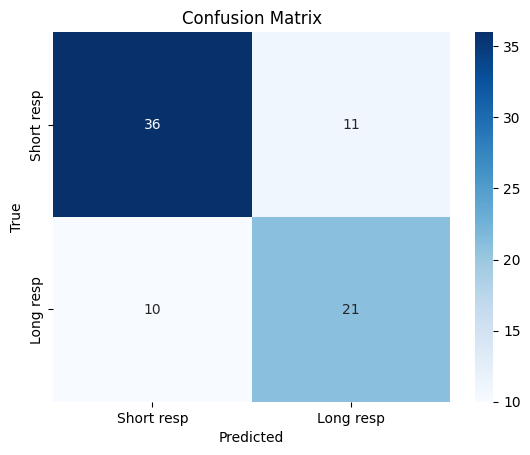

In [31]:
if BINARY_PFS == True:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc', 'f1'],
        return_train_score=True,
        n_jobs=-1
    )
    
    print(f"Train ROC-AUC : {results['train_roc_auc'].mean():.3f} ± {results['train_roc_auc'].std():.3f}")
    print(f"Train  F1     : {results['train_f1'].mean():.3f} ± {results['train_f1'].std():.3f}")
    print(f"Test ROC-AUC  : {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"Test F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}\n")
    
    target_names = ['Short resp', 'Long resp']
else:
    results = cross_validate(
        full_pipe, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    
    print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
    print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")
    print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
    print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
    
    target_names = ['Short resp', 'Intermediate', 'Long resp']

y_pred = cross_val_predict(
    full_pipe, x, y, 
    cv=skf,
    n_jobs=-1
)

print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Evaluation – LeaveOneGroupOut (by cohort)

Cohorts (groups):
source
Yan et al.      61
Kwong et al.    10
Hugo et al.      7

Number of LOGO folds: 3



/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['LDH']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['LDH']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['LDH']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute

      cohort  test_roc_auc  test_f1  train_roc_auc  train_f1
  Yan et al.      0.900000 0.666667       0.982759  0.950820
Kwong et al.      0.720000 0.666667       0.987179  0.909091
 Hugo et al.      0.495495 0.216216       1.000000  1.000000

Train ROC-AUC : 0.990 ± 0.007
Train  F1     : 0.953 ± 0.037
Test ROC-AUC  : 0.705 ± 0.165
Test  F1      : 0.517 ± 0.212


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['LDH']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['LDH']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(



              precision    recall  f1-score   support

  Short resp       0.61      0.74      0.67        47
   Long resp       0.43      0.29      0.35        31

    accuracy                           0.56        78
   macro avg       0.52      0.52      0.51        78
weighted avg       0.54      0.56      0.54        78



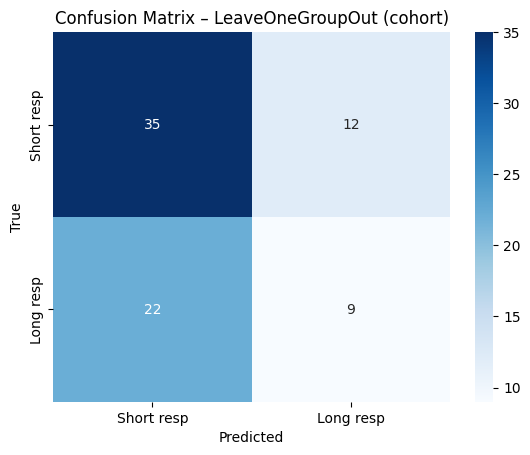

In [ ]:
# logo = LeaveOneGroupOut()
# groups = clinical_gex_filtered['source']

# print("Cohorts (groups):")
# print(groups.value_counts().to_string())
# print(f"\nNumber of LOGO folds: {logo.get_n_splits(groups=groups)}\n")

# if BINARY_PFS:
#     logo_results = cross_validate(
#         full_pipe, x, y,
#         cv=logo,
#         groups=groups,
#         scoring=['roc_auc', 'f1'],
#         return_train_score=True,
#         n_jobs=-1,
#     )

#     fold_df = pd.DataFrame({
#         'cohort':        [g for g in groups.unique()],
#         'test_roc_auc':  logo_results['test_roc_auc'],
#         'test_f1':       logo_results['test_f1'],
#         'train_roc_auc': logo_results['train_roc_auc'],
#         'train_f1':      logo_results['train_f1'],
#     })
#     print(fold_df.to_string(index=False))

#     print(f"\nTrain ROC-AUC : {logo_results['train_roc_auc'].mean():.3f} ± {logo_results['train_roc_auc'].std():.3f}")
#     print(f"Train  F1     : {logo_results['train_f1'].mean():.3f} ± {logo_results['train_f1'].std():.3f}")
#     print(f"Test ROC-AUC  : {logo_results['test_roc_auc'].mean():.3f} ± {logo_results['test_roc_auc'].std():.3f}")
#     print(f"Test  F1      : {logo_results['test_f1'].mean():.3f} ± {logo_results['test_f1'].std():.3f}")
#     target_names = ['Short resp', 'Long resp']

# else:
#     logo_results = cross_validate(
#         full_pipe, x, y,
#         cv=logo,
#         groups=groups,
#         scoring=['roc_auc_ovo', 'f1_macro'],
#         return_train_score=True,
#         n_jobs=-1,
#     )

#     fold_df = pd.DataFrame({
#         'cohort':             [g for g in groups.unique()],
#         'test_roc_auc_ovo':   logo_results['test_roc_auc_ovo'],
#         'test_f1_macro':      logo_results['test_f1_macro'],
#         'train_roc_auc_ovo':  logo_results['train_roc_auc_ovo'],
#         'train_f1_macro':     logo_results['train_f1_macro'],
#     })
#     print(fold_df.to_string(index=False))

#     print(f"\nTrain ROC-AUC (OVO): {logo_results['train_roc_auc_ovo'].mean():.3f} ± {logo_results['train_roc_auc_ovo'].std():.3f}")
#     print(f"Train Macro F1     : {logo_results['train_f1_macro'].mean():.3f} ± {logo_results['train_f1_macro'].std():.3f}")
#     print(f"Test ROC-AUC (OVO) : {logo_results['test_roc_auc_ovo'].mean():.3f} ± {logo_results['test_roc_auc_ovo'].std():.3f}")
#     print(f"Test Macro F1      : {logo_results['test_f1_macro'].mean():.3f} ± {logo_results['test_f1_macro'].std():.3f}")
#     target_names = ['Short resp', 'Intermediate', 'Long resp']

# y_pred_logo = cross_val_predict(
#     full_pipe, x, y,
#     cv=logo,
#     groups=groups,
#     n_jobs=-1,
# )

# print("\n" + classification_report(y, y_pred_logo, target_names=target_names))

# cm_logo = confusion_matrix(y, y_pred_logo)
# sns.heatmap(cm_logo, annot=True, fmt='d',
#             xticklabels=target_names,
#             yticklabels=target_names,
#             cmap='Blues')
# plt.ylabel('True'); plt.xlabel('Predicted')
# plt.title('Confusion Matrix – LeaveOneGroupOut (cohort)')
# plt.show()

In [33]:
selected_per_fold = []
for tr, _ in skf.split(x, y):
    full_pipe.fit(x.iloc[tr], y.iloc[tr])
    names = full_pipe['preprocess'].get_feature_names_out()
    coefs = full_pipe['clf'].coef_[0]
    mask = coefs != 0
    selected_per_fold.append(set(names[mask]))

gex_per_fold = [{f for f in fold if f.startswith('gex__')} for fold in selected_per_fold]

common_gex = set.intersection(*gex_per_fold)
union_gex  = set.union(*gex_per_fold)
sizes_gex  = [len(s) for s in gex_per_fold]

print(f"GEX per-fold sizes : {sizes_gex}")
print(f"GEX in all folds   : {len(common_gex)} → {common_gex}")
print(f"GEX union size     : {len(union_gex)}")
print(f"GEX stability ratio: {len(common_gex) / max(1, min(sizes_gex)):.2f}")

GEX per-fold sizes : [9, 9, 9, 8, 8]
GEX in all folds   : 0 → set()
GEX union size     : 33
GEX stability ratio: 0.00


## Explanability

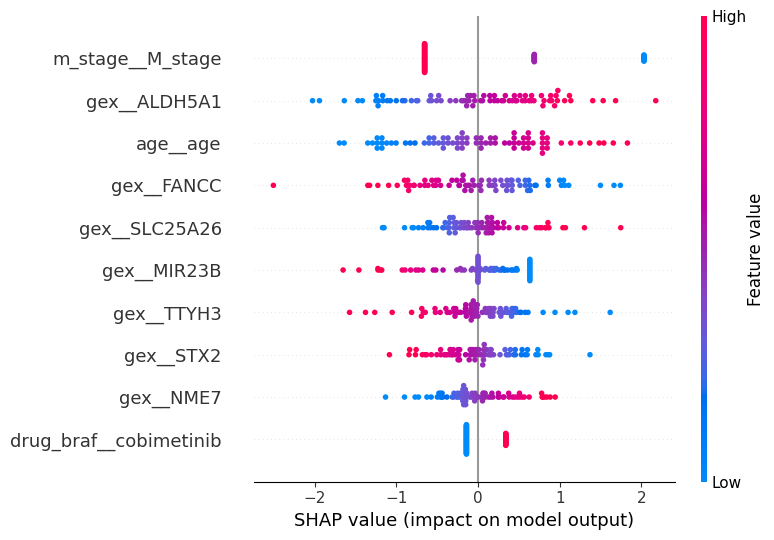

(78, 26)

In [34]:
full_pipe.fit(x, y)

x_transformed = full_pipe[:-1].transform(x)  # x -> prep -> scaler

# Recover feature names after RFE
preprocessed_feature_names = full_pipe['preprocess'].get_feature_names_out()
# selected_mask = full_pipe['selection'].support_
# feature_names = preprocessed_feature_names[selected_mask]
feature_names = preprocessed_feature_names

explainer = shap.LinearExplainer(full_pipe['clf'], x_transformed)
shap_values = explainer(x_transformed)
shap_values.feature_names = feature_names.tolist()

shap.summary_plot(shap_values, x_transformed, feature_names=feature_names, max_display=10)
x_transformed.shape


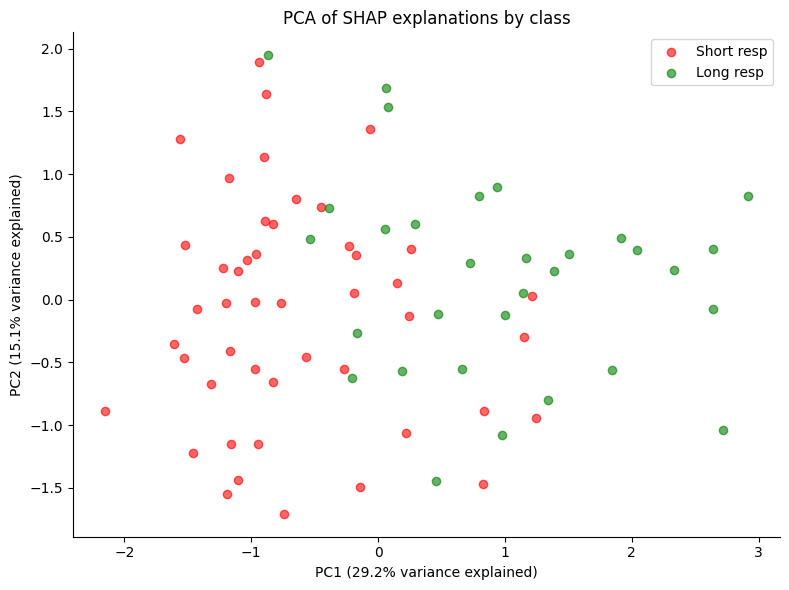

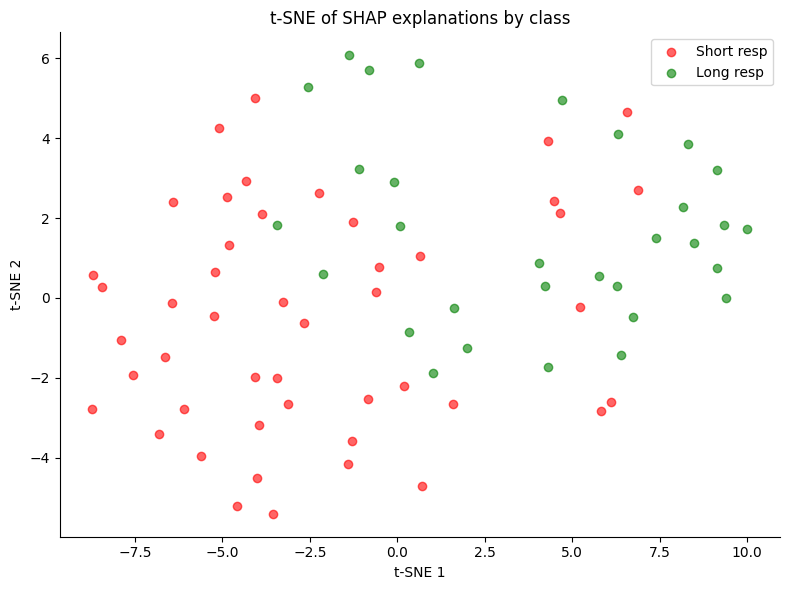

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


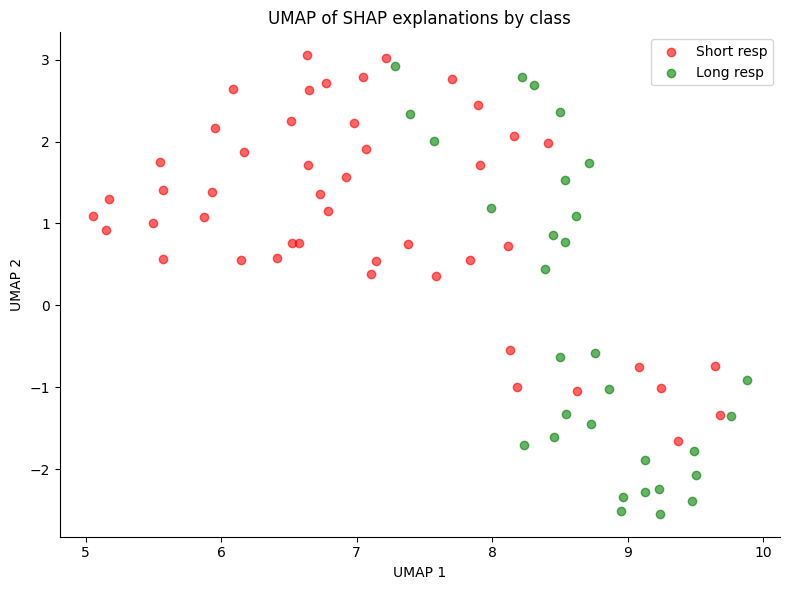

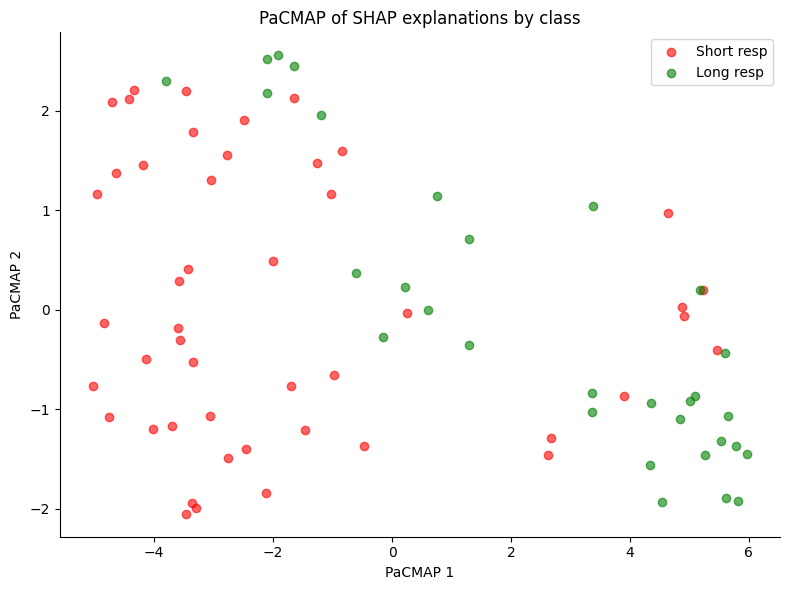

In [35]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

def plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=None):
    if BINARY_PFS:
        colors = {0: "red", 1: "green"}
        labels = {0: "Short resp", 1: "Long resp"}
    else:
        colors = {0: "red", 1: "orange", 2: "green"}
        labels = {0: "Short resp", 1: "Intermediate", 2: "Long resp"}

    fig, ax = plt.subplots(figsize=(8, 6))

    for cls in sorted(colors):
        mask = y_arr == cls
        ax.scatter(
            sv_2d[mask, 0], sv_2d[mask, 1],
            c=colors[cls], label=labels[cls],
            alpha=0.6,
        )

    if var is not None:
        ax.set_xlabel(f"PC1 ({var[0]:.1%} variance explained)")
        ax.set_ylabel(f"PC2 ({var[1]:.1%} variance explained)")
    else:
        ax.set_xlabel(f"{method_name} 1")
        ax.set_ylabel(f"{method_name} 2")

    ax.set_title(f"{method_name} of SHAP explanations by class")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

y_arr = np.array(y)

# For multiclass SHAP, values are (n_samples, n_features, n_classes) — flatten to 2D
if BINARY_PFS:
    sv_input = shap_values.values                              # already (n_samples, n_features)
else:
    sv_input = shap_values.values.reshape(len(y_arr), -1)     # (n_samples, n_features * n_classes)

# PCA — pass explained variance
pca = PCA(n_components=2)
sv_2d = pca.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PCA", var=pca.explained_variance_ratio_)

# t-SNE
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
sv_2d = tsne.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="t-SNE")

# UMAP
u_map = umap.UMAP(n_components=2, random_state=42)
sv_2d = u_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="UMAP")

# PaCMAP
pac_map = pacmap.PaCMAP(n_components=2, random_state=42)
sv_2d = pac_map.fit_transform(sv_input)
plot_shap_reduction(sv_2d, y_arr, method_name="PaCMAP")
